In [1]:
print("Hello, Oslo housing project !")


Hello, Oslo housing project !


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [3]:
data = {
    'borough': ['Frogner', 'Majorstuen', 'Grünerløkka', 'Nordstrand', 'Sagene', 'Stovner', 'Grorud'],
    'price_per_sqm': [124000, 112000, 98000, 72000, 89000, 52000, 48000],
    'average_size_sqm': [68, 72, 65, 82, 70, 91, 88]
}
df = pd.DataFrame(data)
print(df)

       borough  price_per_sqm  average_size_sqm
0      Frogner         124000                68
1   Majorstuen         112000                72
2  Grünerløkka          98000                65
3   Nordstrand          72000                82
4       Sagene          89000                70
5      Stovner          52000                91
6       Grorud          48000                88


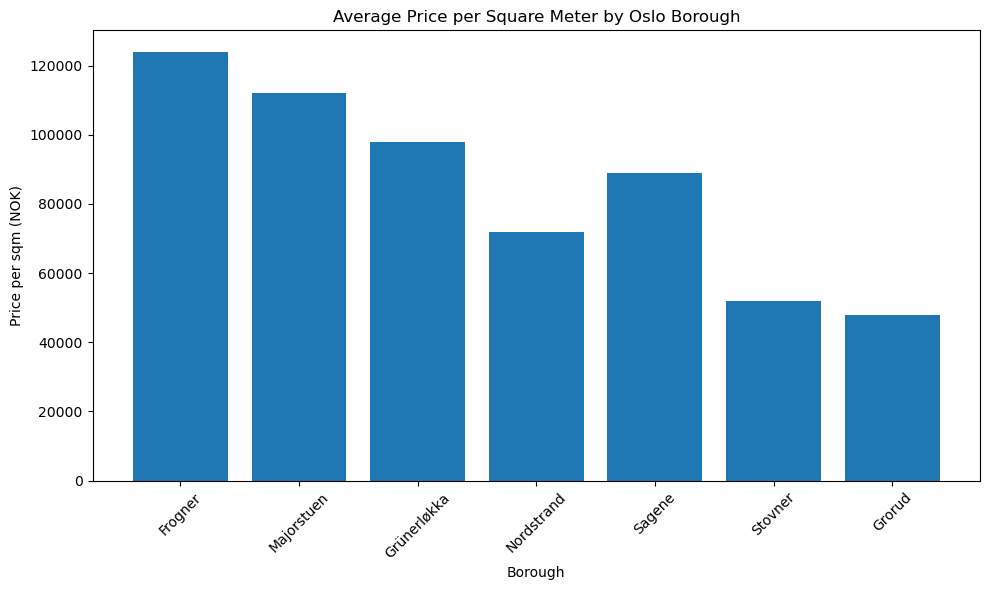

In [4]:
plt.figure(figsize=(10,6))
plt.bar(df['borough'], df['price_per_sqm'])
plt.xticks(rotation=45)
plt.title('Average Price per Square Meter by Oslo Borough')
plt.xlabel('Borough')
plt.ylabel('Price per sqm (NOK)')
plt.tight_layout()
plt.show()


In [6]:
import pandas as pd
import numpy as np

# Set random seed for reproducibility
np.random.seed(42)

# More Oslo boroughs (15 boroughs total)
boroughs = [
    'Frogner', 'Majorstuen', 'Grünerløkka', 'Nordstrand', 'Sagene',
    'Stovner', 'Grorud', 'Bjerke', 'Alna', 'Østensjø',
    'Nordre Aker', 'Ullern', 'Vestre Aker', 'Marka', 'Sentrum'
]

# Create realistic price per sqm (NOK) for 2025
# Based on real market patterns: west expensive, east cheaper
base_prices = {
    'Frogner': 124000, 'Majorstuen': 112000, 'Grünerløkka': 98000,
    'Nordstrand': 88000, 'Sagene': 89000, 'Stovner': 52000,
    'Grorud': 48000, 'Bjerke': 68000, 'Alna': 55000,
    'Østensjø': 72000, 'Nordre Aker': 95000, 'Ullern': 105000,
    'Vestre Aker': 115000, 'Marka': 45000, 'Sentrum': 130000
}

# Generate 500 sample properties
data = []
for _ in range(500):
    borough = np.random.choice(boroughs)
    base_price = base_prices[borough]
    # Add random variation ±15%
    price_variation = np.random.uniform(0.85, 1.15)
    price_per_sqm = int(base_price * price_variation)
    
    # Size: between 30 and 120 sqm
    size_sqm = np.random.randint(30, 121)
    total_price = price_per_sqm * size_sqm
    
    # Building year: between 1900 and 2025
    year_built = np.random.randint(1900, 2026)
    
    # Distance to nearest T-bane station (km)
    distance_t_bane = np.random.exponential(scale=0.8)  # most are close
    distance_t_bane = round(min(distance_t_bane, 5.0), 2)
    
    # Year of sale (2020-2025) – to see price trends
    year_sold = np.random.randint(2020, 2026)
    
    data.append({
        'borough': borough,
        'price_per_sqm': price_per_sqm,
        'size_sqm': size_sqm,
        'total_price': total_price,
        'year_built': year_built,
        'distance_t_bane_km': distance_t_bane,
        'year_sold': year_sold
    })

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (500, 7)


,borough,price_per_sqm,size_sqm,total_price,year_built,distance_t_bane_km,year_sold
0,Grorud,52270,44,2299880,2006,1.21,2024
1,Grorud,47219,116,5477404,1974,0.49,2024
2,Nordstrand,78571,32,2514272,1921,0.05,2023
3,Marka,41116,93,3823788,1959,0.16,2023
4,Østensjø,72534,118,8559012,1948,0.60,2021


In [7]:
df.isnull().sum()


borough               0
price_per_sqm         0
size_sqm              0
total_price           0
year_built            0
distance_t_bane_km    0
year_sold             0
dtype: int64

In [8]:
borough_avg = df.groupby('borough')['price_per_sqm'].mean().sort_values(ascending=False)
borough_avg

borough
Sentrum        130040.896552
Frogner        123565.062500
Vestre Aker    113301.941176
Ullern         108046.906250
Majorstuen     107604.560000
Grünerløkka     98809.076923
Nordre Aker     96812.344828
Nordstrand      89347.176471
Sagene          89229.860465
Østensjø        71250.789474
Bjerke          69144.285714
Alna            54219.562500
Stovner         52225.933333
Grorud          47513.625000
Marka           44413.464286
Name: price_per_sqm, dtype: float64

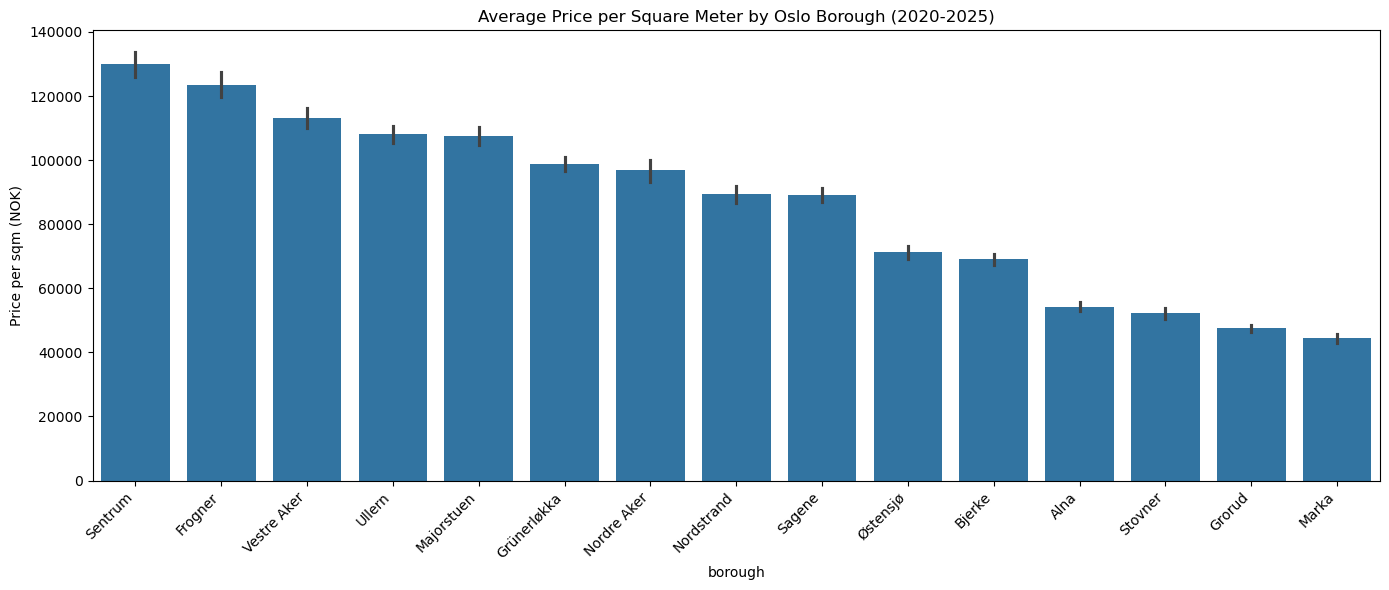

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))
sns.barplot(data=df, x='borough', y='price_per_sqm', order=borough_avg.index)
plt.xticks(rotation=45, ha='right')
plt.title('Average Price per Square Meter by Oslo Borough (2020-2025)')
plt.ylabel('Price per sqm (NOK)')
plt.tight_layout()
plt.show()


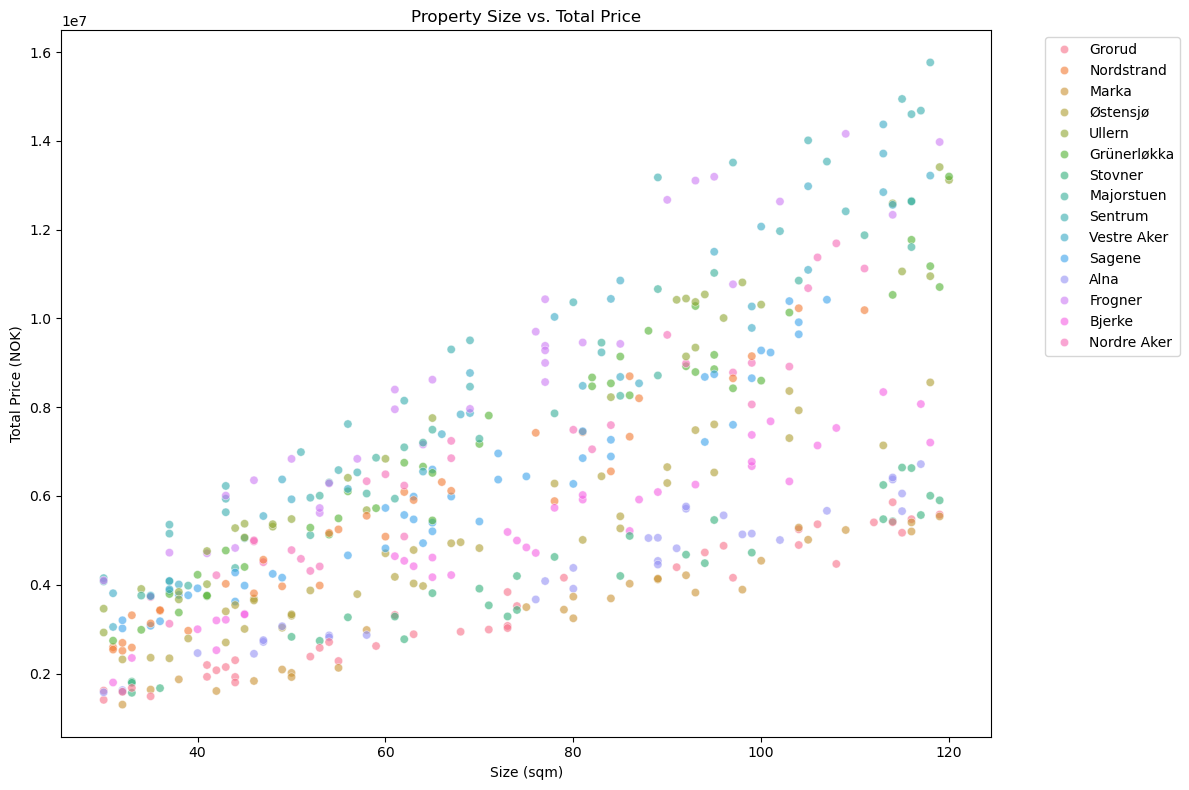

In [10]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='size_sqm', y='total_price', hue='borough', alpha=0.6)
plt.title('Property Size vs. Total Price')
plt.xlabel('Size (sqm)')
plt.ylabel('Total Price (NOK)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

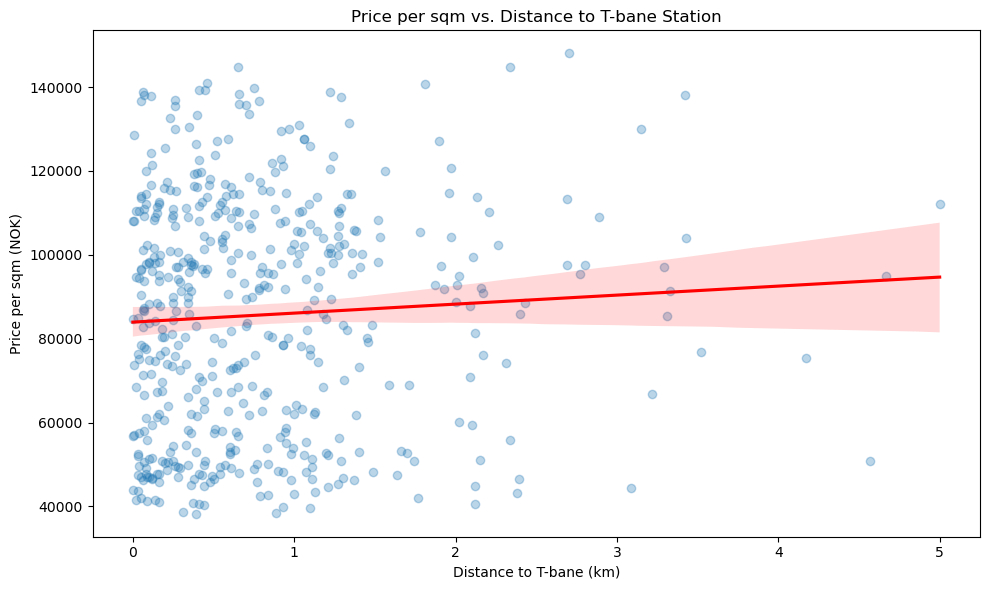

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='distance_t_bane_km', y='price_per_sqm', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Price per sqm vs. Distance to T-bane Station')
plt.xlabel('Distance to T-bane (km)')
plt.ylabel('Price per sqm (NOK)')
plt.tight_layout()
plt.show()

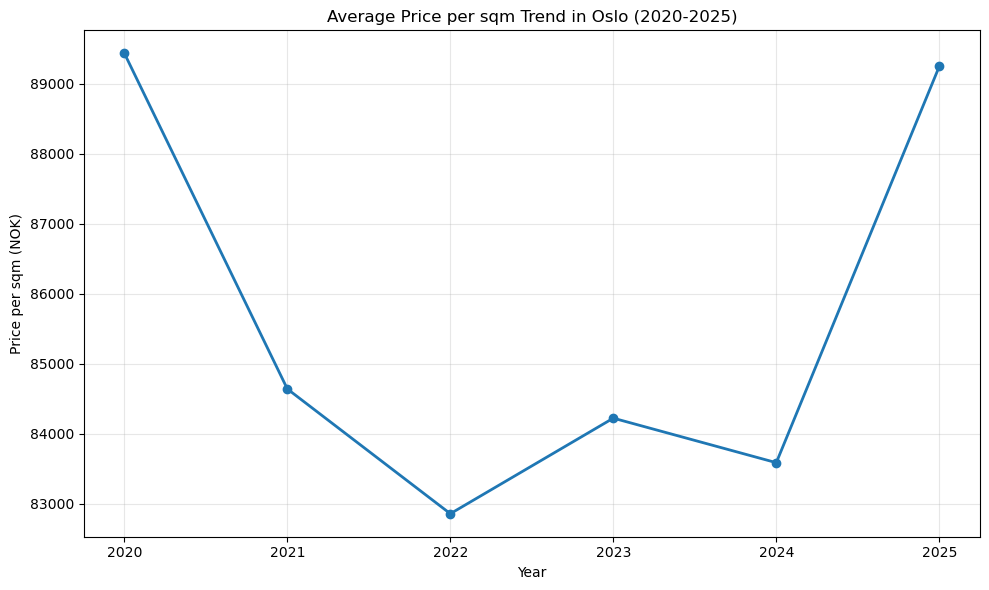

In [12]:
yearly_avg = df.groupby('year_sold')['price_per_sqm'].mean()
plt.figure(figsize=(10, 6))
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linestyle='-', linewidth=2)
plt.title('Average Price per sqm Trend in Oslo (2020-2025)')
plt.xlabel('Year')
plt.ylabel('Price per sqm (NOK)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
affordable = df[(df['price_per_sqm'] < 70000) & (df['distance_t_bane_km'] < 1.0)]
top_boroughs = affordable.groupby('borough').size().sort_values(ascending=False)
print("Best boroughs for budget + proximity to T-bane:")
print(top_boroughs)

Best boroughs for budget + proximity to T-bane:
borough
Grorud      28
Stovner     25
Alna        22
Marka       20
Bjerke      15
Østensjø    12
dtype: int64
